# Explainability & Interpretability

This notebook is focused on explainability and interpretability methods that can help to understand what influences decisions.

## 0 Initialization & Reproducibility

The world of data science involves complex interactions between code, software packages, and hardware. To ensure that you get the same results shown in this tutorial, we have taken specific steps to create a consistent environment. The first cell below installs the exact versions of the software libraries (scikit-learn, pandas, numpy, etc.) that were used to generate the final results in this notebook, together with a Google Colab environment with Python 3, available in November 2025 (version 2025.10). The package versions are set to match the mentioned Colab's environment. Morever, many procedures and algorithms in this notebook are based on randomness, therefore, we also fix the numpy random state, and pass fixed `RANDOM_STATE` values to functions from scikit-learn, to create as much reproducible code and results as possible. Unfortunately, with changing environment it is possible that results will slightly differ. However, it does not affect general principles and messages of this notebook.


In [1]:
# Install dependencies with versions matching Google Colab environment 10.2025 with Python 3
%pip install pandas==2.2.2 numpy==2.0.2 matplotlib==3.10.0 seaborn==0.13.2 graphviz==0.21 shap==0.49.1 lime==0.2.0.1 wget==3.2 scikit-learn==1.6.1 pyarrow==18.1.0

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

Here, we will also prepare a function that takes the ground truth labels of a dataset and the corresponding predictions from the evaluated machine learning model. The function then calculates the standard metrics used in model evaluation and prints them.

In [3]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score

def evaluate_model(y_true, y_pred, variant='macro', digits=4):
    print(f'Metrics are in their {variant} variant')

    # Calculate the metric and then scale it to percentages
    acc = round(100 * accuracy_score(y_true, y_pred), digits)
    rec = round(100 * recall_score(y_true, y_pred, average=variant), digits)
    pre = round(100 * precision_score(y_true, y_pred, average=variant), digits)
    f1s = round(100 * f1_score(y_true, y_pred, average=variant), digits)

    print(f'Accuracy  : {acc} %')
    print(f'Recall    : {rec} %')
    print(f'Precision : {pre} %')
    print(f'F1-Score  : {f1s} %')

### Dataset

We will use the dataset prepared in [02a-data-preparation.ipynb](../02-app-classification/02a-data-preparation.ipynb). The dataset contains 10 classes and features based on Sequence of Packet Lengths and Times (SPLT), and it was created and saved under the name `final_dataset_10_classes_splt.parquet` in the 02-data-preparation tutorial. Therefore, we will firstly download this dataset (if it has not been downloaded yet). The data is already prepared, therefore, we just have to load it in a way we can easily use it later. We will only use a sequence of packet lengths, to keep the number of features feasible, for increased readability. Feature `PS_{i}` contains a size of the i-th packet. Target variable `y` contains class names, such as `Download` or `Game`.


Firstly, we download the parquet file with the dataset.

In [ ]:
import os

DATA_FOLDER = 'data'
DATASET_FILENAME = 'final_dataset_10_classes_splt.parquet'
FULL_DATASET_PATH = f'{DATA_FOLDER}/{DATASET_FILENAME}'

# Ensure that data folder exists
os.makedirs(DATA_FOLDER, exist_ok=True)

# If we do not have the .parquet file downloaded yet, download it
if not os.path.isfile(FULL_DATASET_PATH):
    print(f'Downloading dataset to {FULL_DATASET_PATH}...')
    # Clone the project repository (without downloading all blobs)
    !git clone --filter=blob:none --sparse -n https://github.com/FlowFrontiers/ml-flow-class-tutorial.git 2> >(grep -v '^remote:')

    # Navigate into the repo and select only the data files we need
    !cd ml-flow-class-tutorial && git sparse-checkout set 02-app-classification/data/final_dataset_10_classes_splt.parquet
    !cd ml-flow-class-tutorial && git checkout 2> >(grep -v '^remote:')

    # Copy the dataset to the data/ folder of this notebook
    !mv ml-flow-class-tutorial/02-app-classification/data/final_dataset_10_classes_splt.parquet data/
else:
    print(f'Dataset is already downloaded in {FULL_DATASET_PATH}!')

Dataset is already downloaded in data/final_dataset_10_classes_splt.parquet!


Then, we load the parquet file with the data as a pandas DataFrame. Then, we will obtain the length of sequences (marked as `N`) in the loaded data, and split the column with the sequence information into separate columns for each position. Flows that did not contain `N` packets were padded with `-1`. Finally, we inspect shapes of the loaded data and showcase a flow that was padded to the target `N` length.

In [5]:
import ast

dataframe = pd.read_parquet(FULL_DATASET_PATH)
print(f"Loaded dataset has the following shape: {dataframe.shape}")

dataframe['PACKET_SIZE_SEQUENCE'] = dataframe['splt_ps'].apply(ast.literal_eval)

N = dataframe['PACKET_SIZE_SEQUENCE'].str.len().max()
print(f"The maximum sequence length (N) for SPLT features is: {N}")

# Convert columns and prepare X (feature) dataset
X = pd.DataFrame(dataframe['PACKET_SIZE_SEQUENCE'].to_list(), columns=[f'PS_{i+1}' for i in range(N)])

# Prepare y dataset (a series of ground truth labels)
y = dataframe['application_category_name']
print(f"\nFeature matrix X has the following shape:: {X.shape}")
print(f"Target vector y has the following shape:: {y.shape}")

# Find a flow that has been padded
short_flow_sample = X[dataframe['application_name'] == 'BitTorrent'].tail(1)
print("\n--- Sample of a short flow with -1 padding ---")
display(short_flow_sample)

Loaded dataset has the following shape: (106528, 5)
The maximum sequence length (N) for SPLT features is: 25

Feature matrix X has the following shape:: (106528, 25)
Target vector y has the following shape:: (106528,)

--- Sample of a short flow with -1 padding ---


,PS_1,PS_2,PS_3,PS_4,PS_5,PS_6,PS_7,PS_8,PS_9,PS_10,...,PS_16,PS_17,PS_18,PS_19,PS_20,PS_21,PS_22,PS_23,PS_24,PS_25
106499,32,32,20,88,20,88,53,1480,1480,1480,...,20,102,20,25,20,-1,-1,-1,-1,-1


After loading, we will split the dataset into train/test sets with 80:20 ratio. Moreover, we will use stratified split controlled by `y`, to keep the same class ratios in both sets as it was in the original dataset.

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

We quickly investigate features in the dataset and what classes are present.

In [7]:
X_train

,PS_1,PS_2,PS_3,PS_4,PS_5,PS_6,PS_7,PS_8,PS_9,PS_10,...,PS_16,PS_17,PS_18,PS_19,PS_20,PS_21,PS_22,PS_23,PS_24,PS_25
96082,1258,1258,90,48,1258,1258,306,960,45,86,...,670,596,269,32,128,33,33,33,37,33
84564,1208,1240,1240,1221,88,1208,50,81,42,62,...,280,56,90,90,1260,44,56,1240,1240,984
75223,32,32,20,1480,593,20,20,284,100,112,...,81,51,20,51,20,175,989,20,584,20
26483,80,80,80,60,60,60,60,60,80,80,...,68,-1,-1,-1,-1,-1,-1,-1,-1,-1
32813,44,40,32,604,32,1372,1372,1372,194,32,...,1340,441,32,559,32,32,63,514,32,32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68313,1258,1258,88,48,1258,1258,306,960,79,32,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
92926,32,32,20,1480,290,20,20,1480,1480,1046,...,20,307,307,81,51,20,51,20,219,64
10965,1258,1258,48,1258,1258,1258,1258,1258,1258,1247,...,49,91,82,968,129,42,41,41,32,195
47917,1258,1258,88,48,1258,1258,1258,305,952,86,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1


In [8]:
y_train.value_counts()

application_category_name
Web              20785
Collaborative    18486
SocialNetwork    16883
Media             9841
Game              5477
Advertisement     5049
Music             4804
Download          3698
Cloud              199
Name: count, dtype: int64

## 1 Trivially Interpretable Models

### 1.1 Linear & Logistic Regression

Some models are trivially interpretable as their inner functionality is known, simple, and results can be easily interpreted.
<br />
As an example, consider a Linear Regression model. Inner functionality is directed by the following formulae:

$$\mathbf{y} = X \beta + \varepsilon $$


After the training is finished, the coefficients (beta vector) are known and can be used to interpret indiviual decisions. However, keep in mind that each coefficient is affected by the values and scales of the corresponding feature, therefore, meaning of the coefficients is different than feature importance. Moreover, the larger the coefficient **does not** mean the bigger importance. We need to be careful with such importance estimation, because features must have similar scales. However, we use packet sizes which can have values from a range `0-1500` (MTU). Moreover, even if a coefficient is negative, it has an impact, just in the opposite way. It is important to evaluate coefficients in absolute values.


Remember that Linear Regression is a regression model, therefore used for predicting continuous variable. We cannot use it to predict a traffic class. Therefore, we will take one class from the original dataset for this example. The task will be to predict the size of the first packet (TLS ClientHello) from the remaining packet sizes. Firstly, we will create a filtered dataset, then the Linear Regression model will be trained, and learned coefficients will be analyzed afterwards.

In [9]:
LR_SELECTED_CLASS = 'Download'
LR_train_df = X_train[y_train == LR_SELECTED_CLASS]
LR_test_df = X_test[y_test == LR_SELECTED_CLASS]

LR_TARGET_VARIABLE = 'PS_1'
LR_FEATURES = LR_train_df.columns.to_list()
LR_FEATURES.remove(LR_TARGET_VARIABLE)

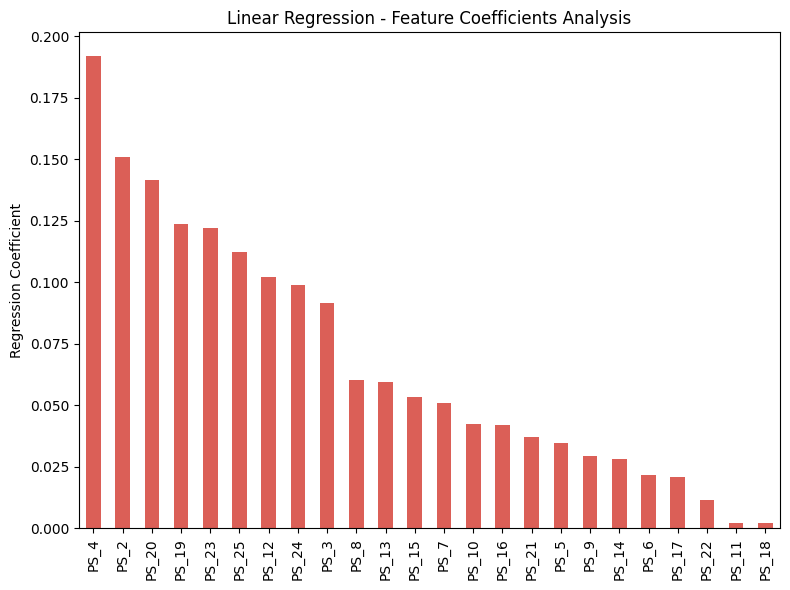

In [10]:
from sklearn.linear_model import LinearRegression

# Create and train Linear Regression model
lnr_clf = LinearRegression()
lnr_clf.fit(LR_train_df[LR_FEATURES], LR_train_df[LR_TARGET_VARIABLE])

# Obtain learned coefficients
coefficients = {}
for idx, feature in enumerate(LR_FEATURES):
    # Note that we take the absolute value of the coefficient
    coefficients[feature] = abs(lnr_clf.coef_[idx])
    #print(feature, coefficients[feature])

# Sort features by their coefficients
coefficients = dict(sorted(coefficients.items(), key=lambda item: item[1], reverse=True))

# Plot features and their respective coefficients
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
_ = pd.Series(coefficients).plot.bar(color=sns.color_palette("hls", 1))
ax.set_title("Linear Regression - Feature Coefficients Analysis")
ax.set_ylabel("Regression Coefficient")
fig.tight_layout()

Coefficient for the `PS_4` (size of the 4th packet) is the largest and suggests that the feature has large influence on the target variable and overall outcome of the model. We cannot feasibly plot the dependance of all the features and the target variable, but we can choose one feature and examine it. As the `PS_4` has the largest coefficient, we will focus on it. We will create a `numpy.linspace` to capture the full value spectrum of the `PS_4`. The rest of the features must remain constant, otherwise we would not see the marginal effect of the examined feature. Therefore, we will fix the remaining features by their means. The resulting plot will show how the examined feature influences the overall outcome.

In [11]:
def lr_examine_feature(train_df, examined_feature, target_variable, target_count):
    dataset_for_plot = pd.DataFrame()

    for column in LR_FEATURES:
        if column == examined_feature:
            # Fill the selected feature values with samples from its original range
            dataset_for_plot[examined_feature] = np.linspace(train_df[examined_feature].min(), train_df[examined_feature].max(), target_count)
        else:
            # All other features will remain constant: we will use their mean as an approximation, repeated to the same length
            dataset_for_plot[column] = [train_df[column].mean()] * target_count

    # Now predict values with the originally trained model
    y_pred = lnr_clf.predict(dataset_for_plot)

    # Plot
    plt.scatter(train_df[examined_feature], train_df[target_variable], color=sns.color_palette('hls', 1)[0], label='Samples')
    plt.plot(dataset_for_plot[examined_feature], y_pred, color=sns.color_palette('hls', 2)[1], label='Regression curve')

    plt.xlabel(examined_feature)
    plt.ylabel(target_variable)
    plt.legend()
    plt.title(f'Regression Curve - {examined_feature} and {target_variable}')

    plt.tight_layout()
    plt.show()

/Users/plny/Documents/CESNET/ml-flow-class-tutorial/.venv/lib/python3.12/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/plny/Documents/CESNET/ml-flow-class-tutorial/.venv/lib/python3.12/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/plny/Documents/CESNET/ml-flow-class-tutorial/.venv/lib/python3.12/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


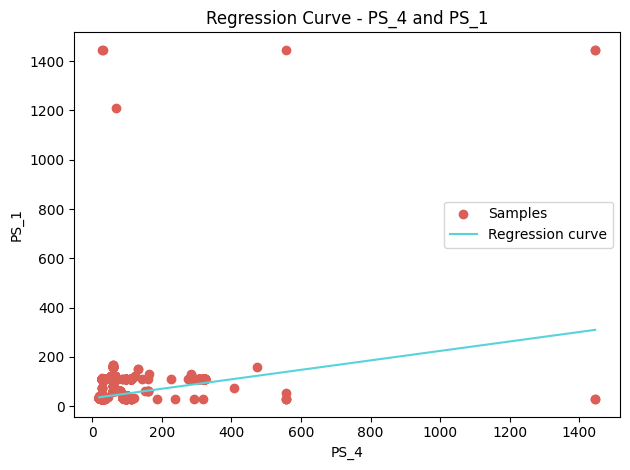

In [12]:
# Examine influence of the PS_4
# Parameter target_count is used to sample the value space of the examined feature
lr_examine_feature(LR_train_df, 'PS_4', 'PS_1', 100)

The plot above shows the relationship between feature `PS_4` and the target variable `PS_1`. We can see that as the size of the 4th packet increases, so does the predicted value of the 1st packet. Therefore, we can summarize the marginal effect of the examined feature as that predicted size of the 1st packet is larger with the larger values of the 4th packet. We can also examine how a feature with small coefficient affects the overall prediction. For example, we will examine the `PS_18`, shown below.

/Users/plny/Documents/CESNET/ml-flow-class-tutorial/.venv/lib/python3.12/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/plny/Documents/CESNET/ml-flow-class-tutorial/.venv/lib/python3.12/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/plny/Documents/CESNET/ml-flow-class-tutorial/.venv/lib/python3.12/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


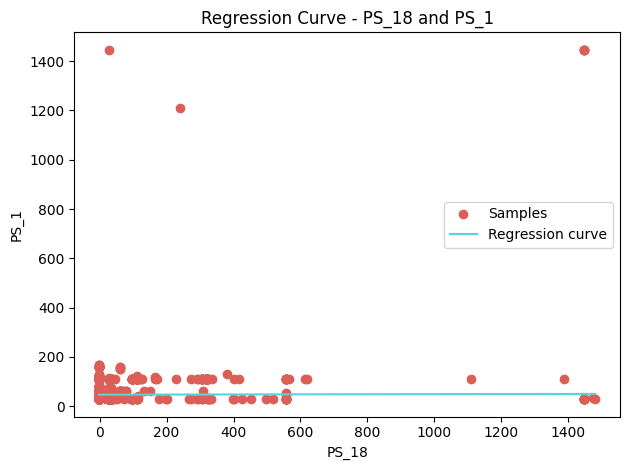

In [13]:
# Examine influence of the PS_18
# Parameter target_count is used to sample the value space of the examined feature
lr_examine_feature(LR_train_df, 'PS_18', 'PS_1', 100)

We used the same method for examining the contribution of the `PS_18` and we can see that the predicted values stay almost constant with changing values of the `PS_18`. Marginal effect of this feature is therefore non-relevant, as the predicted values are not affected at all.


The similar can be performed for Logistic Regression, however, in the case of Logistic Regression, the exponents do not have a linear impact, but exponential.

### 1.2 Tree-based Models

Tree-based models also have several model-specific explainability methods:
1. Individual trees can be plotted and visually inspected.
2. Feature importance can be calculated through impurity measurements.


Here, we will again firstly prepare a dataset. We will take two classes from the original dataset, effectively creating a binary classification task. Random Forest will be applied, as it is a tree-based method. Moreover, we will limit `max_depth` and number of estimaors, to keep the model simple. One of the techniques is visualization and deep trees might be difficult to inspect in a Jupyter notebook. Visualization methods are of course not limited to a max depth, but it would be preferable to save the visualization in a high quality to a separate file and inspect it in a viewer, for example. Visualization methods for such cases would be used in the same way as in this Jupyter notebook, but with a higher quality settings.

In [14]:
RF_X_train = X_train[(y_train == 'Game') | (y_train == 'Download')]
RF_y_train = y_train[(y_train == 'Game') | (y_train == 'Download')]

RF_X_test = X_test[(y_test == 'Game') | (y_test == 'Download')]
RF_y_test = y_test[(y_test == 'Game') | (y_test == 'Download')]

Firstly, we will train the Random Forest classifier on the binary task and perform a simple evaluation of its performance.

In [15]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(max_depth=3, n_estimators=3, random_state=RANDOM_STATE)

# .fit() method is used to train the Random Forest model on our train set
# The first argument is the feature set, the second argument is a list of ground truth labels
random_forest.fit(RF_X_train, RF_y_train)

# After the classifier is trained, we then take test set and let the trained model predict labels
y_pred = random_forest.predict(RF_X_test)

# Calculate performance metrics through the our function defined earlier
# The first argument contains ground truth labels, the second argument contains labels predicted by the model
# By comparing them, we can evaluate the overall model performace
evaluate_model(RF_y_test, y_pred)

Metrics are in their macro variant
Accuracy  : 98.43 %
Recall    : 98.1047 %
Precision : 98.6528 %
F1-Score  : 98.3596 %


The Random Forest is trained and ready for examination.

#### 1.2.1 Visualization

The scikit-learn library directly contains a function for plotting `DecisionTreeClassifier` object called `plot_tree()`. As Random Forest is a set of Decision Trees, we can access the trained trees in the forest through `estimators_` attribute and plot them. We will examine the first tree of the trained Random Forest classifier. Note that our classes are in a form of uints, but the `plot_tree()` needs strings. Therefore, we must perform type conversion. Different trees of the classifier can be examined by setting a different access index to the `estimators_` list. The `plot_tree()` function can be used to the standard Decision Tree models as well, in scikit-learn called `sklearn.tree.DecisionTreeClassifier()`.


Each node has its condition used to split the data. If the condition is satisfied, the left path is taken and the condition from the next left child is evaluated. Then, gini measures how much is the node pure: node with the gini 0 contains samples of only one class and is considered pure. The higher the gini index, the more mixed classes are present in the node. Samples specify how many samples in the training phase reached this node. Value defines how many samples of each class (the same ordering as in the list passed to `class_names`) reached this node, and finally, defines a classification output if a sample ends in this node. It is a majority from the `value`.


Be careful about values passed to the `class_labels` parameter. Scikit's decision trees internally use `numpy.unique()` to obtain unique labels in the y vector and then store them in the `classes_` attribute. Therefore, we will use the same call to obtain unique values. Without setting the `class_labels` parameter, there would only be integers as class names, and it would be harder to understand the model.

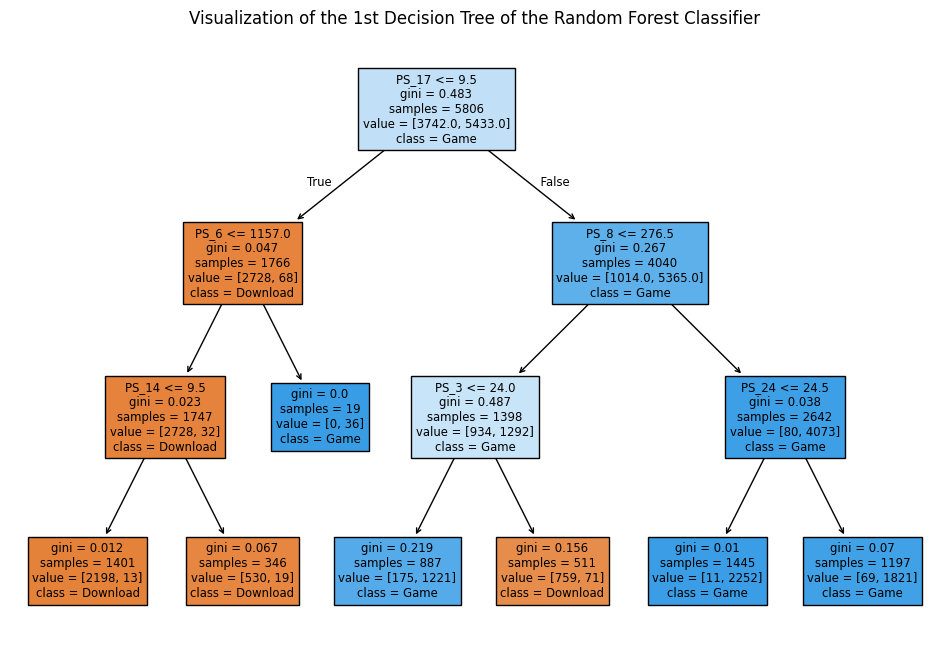

In [16]:
from sklearn.tree import plot_tree

plt.figure(figsize=(12,8), dpi=100)

dec_tree = random_forest.estimators_[0]
plot_tree(dec_tree, filled=True, feature_names=RF_X_train.columns, class_names=np.unique(RF_y_train))

plt.title('Visualization of the 1st Decision Tree of the Random Forest Classifier')
plt.show()

The plotted structure nicely shows how a decision would be made for any input sample. We can follow a path from root based on the conditions and input sample features to a leaf, where a final decision would be made as a majority of samples that reached this leaf. In the case of full Random Forest, the final decision is a majority.


There also is **graphviz** package and `export_graphviz()` method, an alternative to the `plot_tree()` used in the first example above. However, Python's **graphviz** package has to be installed, and **graphviz** binaries must be installed as well. Quick installation commands are provided below, however, we kindly ask the reader to follow official installation guides.
```bash
# RHEL-based Linux systems
sudo dnf install graphviz

# Debian-based Linux systems
sudo apt-get install graphviz

# Python's package installation
pip install graphviz
```

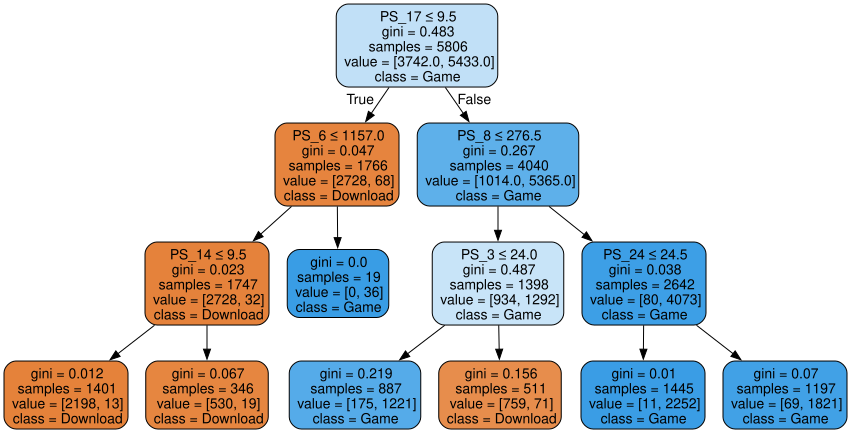

In [17]:
import graphviz
from sklearn.tree import export_graphviz

# Export graphviz data though scikit's tree.export_graphviz function
dot_data = export_graphviz(
    dec_tree,
    out_file=None,
    feature_names=RF_X_train.columns.to_list(),
    class_names=np.unique(RF_y_train),
    filled=True,
    rounded=True,
    special_characters=True
)

# Create graphviz object from the exported data
graph = graphviz.Source(dot_data)

# Set preferred output to SVG, for GitHub compatibility
# Otherwise, some characters might not be rendered
graph.format = 'svg'

# Render the graph
graph

#### 1.2.2 Permutation Importance through Gini Impurity

In the case of the tree-based models, feature importance can be measured though so-called Gini impurity. As previously mentioned, Gini impurity measures how much classes are mixed inside a node. We can also calculate Gini impurity of the whole tree. Then, we can calculate how much Gini impurity decreases and, therefore, how much the split helped. When the tree is built and training is finished, we can calculate feature importances based on how much each feature helped to reduce the impurity and distinguish the data. In addition, we can average the Gini impurity across the forest and obtain overall feature importance. We will also plot standard deviations, as it is also available and can provide reasonable information.

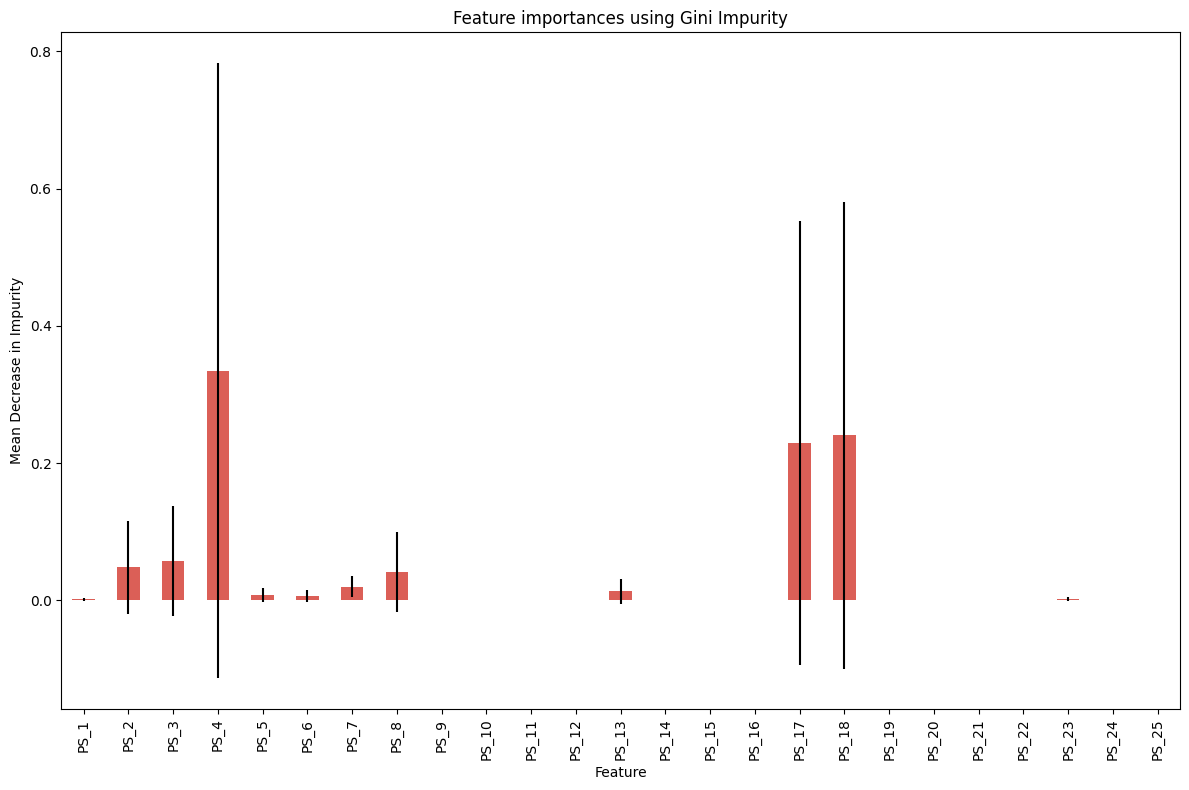

In [18]:
import seaborn as sns

forest_importances = pd.Series(random_forest.feature_importances_, index=RF_X_train.columns.to_list())
std = np.std([tree.feature_importances_ for tree in random_forest.estimators_], axis=0)

fig, ax = plt.subplots(figsize=(12,8), dpi=100)
forest_importances.plot.bar(
    yerr=std,
    ax=ax,
    color=sns.color_palette("hls", 1),
)
ax.set_title("Feature importances using Gini Impurity")
ax.set_xlabel("Feature")
ax.set_ylabel("Mean Decrease in Impurity")
fig.tight_layout()

In the plotted feature importances calculated through Gini impurity, we can see that `PS_4`, followed by `PS_17` and `PS_18`, caused the highest decreases in the impurity index. It is in agreement with what we learned from the visualization, where `PS_17` is used in the root node of the first tree. Note that `PS_18` was used in the root node of the second tree, and the `PS_4` in the root of the third three. Many features have insignificant importance in this case, but it can also be caused by high number of features and not enough splits: we kept the model simple with three estimators with max depth of three.

## 2 Permutation Feature Importance

Not all models provide an attribute with feature importances. Therefore, we must calculate feature importances on our own, for example with permutation feature importance: a model-agnostic method that can be used for any model. Feature values are permutated and feature importance is evaluated according to the performance drop. The more the drop, the more significant the feature is as the model uses it for the final prediction. If a feature is randomly shuffled and the model performance is not changed much, it indicates that the feature is not important for the model predictions.


The scikit-learn library has a function `permutation_importance` for calculating the feature importance with the following parameters:
- `clf`: fitted classifier to explore
- `X`: data (feature set) to explore
- `y`: ground truth for the passed feature set
- `n_repeats`: the number of times features are permuted
- `random_state`: seed value for random generator


Source: [scikit-learn docs](https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_importances.html)


In this example, we will calculate feature importances through the `permutation_importance()` for the same Random Forest classifier used previously, display the importances, and also plot them as a bar plot together with the standard deviations. The returned object from the `permutation_importance()` function is a dictionary and it contains the importances themselves, and then already calculated means and standard deviations. We will transform it into a pandas DataFrame object, so we can better work with it. The `importances` key contains the actual importances and performance drops, but sicne we already have the statistics calculated, we will drop this key/column. Then, the DataFrame object will be created. We will also sort features by their importances.

In [19]:
from sklearn.inspection import permutation_importance

# Calculate permutation feature importances
result = permutation_importance(
    random_forest,
    RF_X_train,
    RF_y_train,
    n_repeats=10,
    random_state=RANDOM_STATE
)

# The result object contains the following keys: importances, importances_mean, and importances_std
print(f'Keys in the result object: {result.keys()}')

# Delete the importance key: we do not need the values and it would only cause problems when creating the DataFrame since it has different shape
# then the rest of the columns
del result['importances']
importances_df = pd.DataFrame(result, index=RF_X_train.columns.to_list()).sort_values(by='importances_mean', ascending=False)
importances_df

Keys in the result object: dict_keys(['importances_mean', 'importances_std', 'importances'])


,importances_mean,importances_std
PS_4,0.177668,0.002225
PS_3,0.024327,0.000812
PS_8,0.011444,0.000769
PS_2,0.008480,0.000595
PS_23,0.004719,0.000682
PS_7,0.003717,0.000521
PS_1,0.001144,0.000214
PS_13,0.001068,0.000228
PS_9,0.000480,0.000208
PS_22,0.000327,0.000218


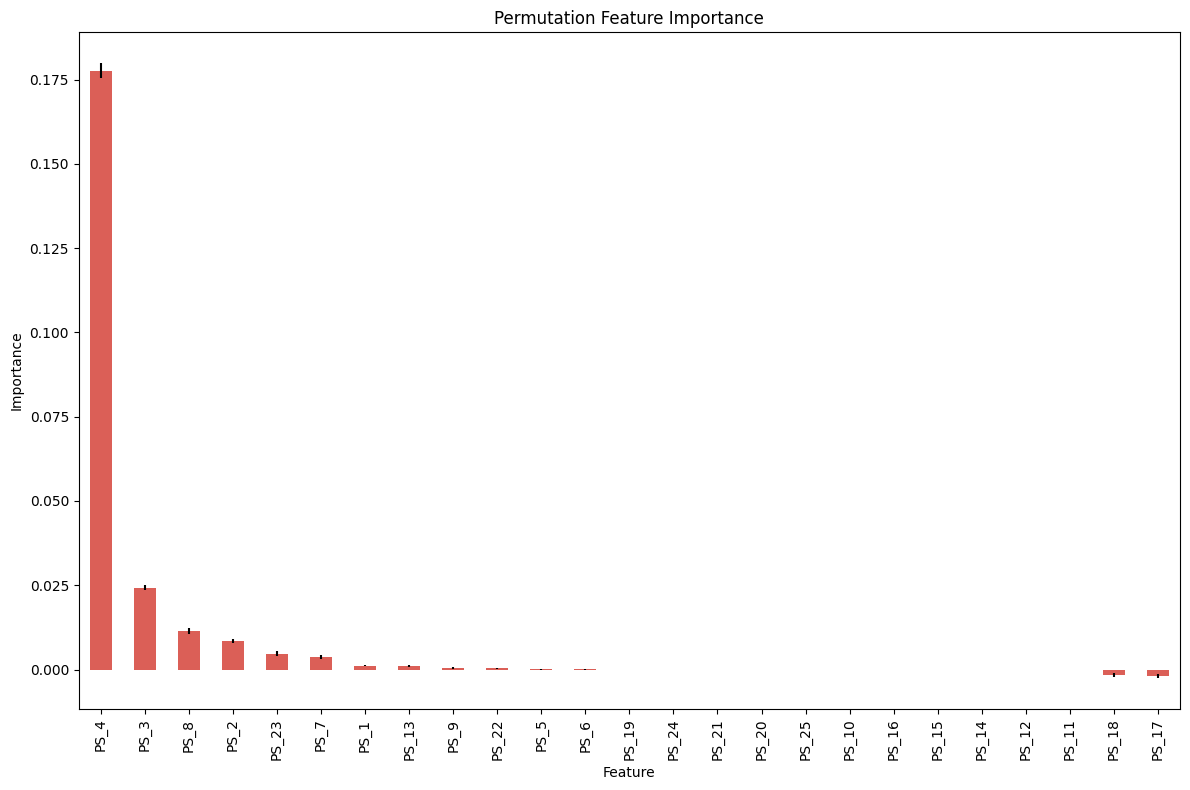

In [20]:
fig, ax = plt.subplots(figsize=(12,8), dpi=100)
importances_df['importances_mean'].plot.bar(
    yerr=importances_df['importances_std'],
    ax=ax,
    color=sns.color_palette("hls", 1),
)
ax.set_title("Permutation Feature Importance")
ax.set_xlabel("Feature")
ax.set_ylabel("Importance")
fig.tight_layout()
plt.show()

According to the plot above, `PS_4`, `PS_3`, and `PS_8` are the top three most important features. However, we must be very careful with such results and conclusions, because permutation feature importance does not perform well with **correlated** features! If we only permutate one feature and not all the ones that are correlated between each other, we can get skewed results. Another feature can still provide the needed information to the model to make a correct prediction and performance drop will not be as significant. We need to permutate all the correlated features. Therefore, we should have checked correlation before running the algorithm. We will now fix it. Firstly, we will check if any features are correlated, create groups of features that are correlated with each other, and then run the algorithm again. But now, we will permutate all features in the corresponding group.


Firstly, we obtain correlation matrix. As each feature is correlated to each other, the elements on the diagonal are useless to us. Moreover, as the matrix is symmetrical, we can only use the elements above the diagonal. Therefore, we nullate all the other elements to ease the investigation. Then, we will iterate through all the pairs in the matrix and print the features that are highly correlated with each other, above a pre-defined threshold. In this case, we will set the threshold to `0.75`.

In [21]:
# We will also track correlated groups of features
def add_correlated_pair(table, feature1, feature2):
    found = False
    for group in table:
        if feature1 in group or feature2 in group:
            group.update([feature1, feature2])
            found = True
    if not found:
        table.append(set())
        table[-1].update([feature1, feature2])
    return table

In [22]:
# Obtain correlation matrix
correlation_matrix = RF_X_train.corr().abs()
# Nullate elements on the diagonal and below
correlation_matrix = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

CORRELATION_THRESHOLD = 0.75

print(f'Features that are correlated more than {CORRELATION_THRESHOLD}:')

feature_groups = []

for row in correlation_matrix.index:
    for col in correlation_matrix.columns:
        # We will skip the nullated elements
        if np.isnan(correlation_matrix[col][row]):
            continue

        # Check the correlation
        if correlation_matrix[col][row] > CORRELATION_THRESHOLD:
            coefficient = round(correlation_matrix[col][row], 2)
            print(f'Feature 1: {row:<5}\tFeature 2: {col:<5}\tCorrelation Coefficient: {coefficient}')
            feature_groups = add_correlated_pair(feature_groups, row, col)

Features that are correlated more than 0.75:
Feature 1: PS_6 	Feature 2: PS_7 	Correlation Coefficient: 0.92
Feature 1: PS_21	Feature 2: PS_22	Correlation Coefficient: 0.76
Feature 1: PS_22	Feature 2: PS_23	Correlation Coefficient: 0.78
Feature 1: PS_23	Feature 2: PS_24	Correlation Coefficient: 0.79
Feature 1: PS_24	Feature 2: PS_25	Correlation Coefficient: 0.83


We can also use hierarchical clustering based on the correlation coefficients and visualize the feature hierarchy and groupping, as shown in [this tutorial](https://scikit-learn.org/stable/auto_examples/inspection/plot_permutation_importance_multicollinear.html#handling-multicollinear-features).


We will use correlation coefficients to estimate a distance metric and then plot features in hierarchical clusters. Therefore, we will see what features can be groupped together. The dendrogram plot shows all features finally merging together, however, with the large distance. Similarly as we defined a threshold for correlation, we can define a threshold for the distance-based metric and color groups of features in a certain distance. However, distance-based metric estimation can differ and slighly different groups of features can be identified, even though the structure shows the ame behavior.

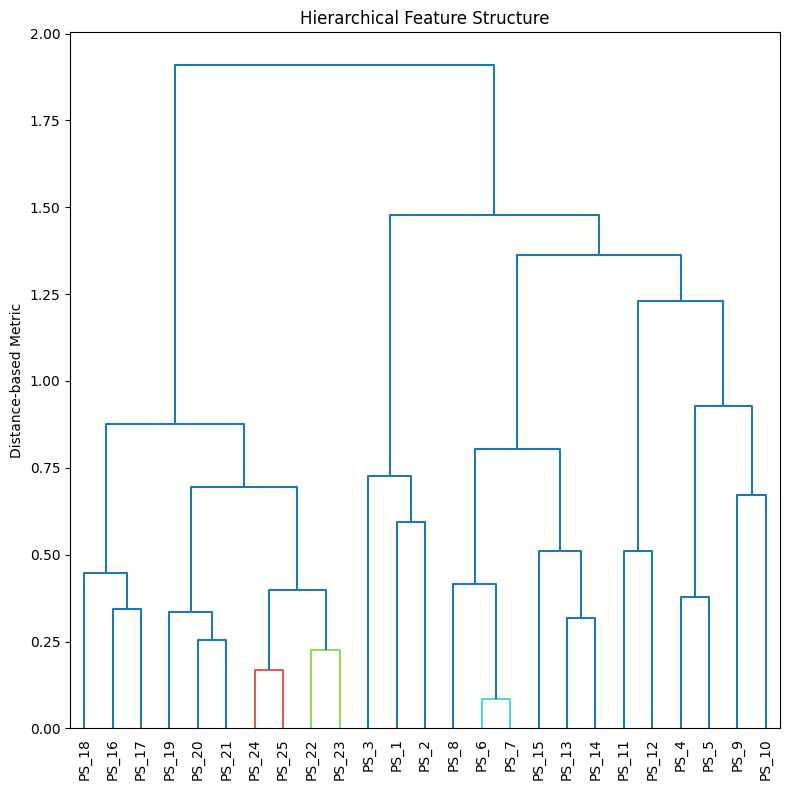

In [23]:
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

correlation = RF_X_train.corr().abs().to_numpy()
correlation = (correlation + correlation.T) / 2
np.fill_diagonal(correlation, 1)

distance_matrix = 1 - np.abs(correlation)
distance_linkage = hierarchy.ward(squareform(distance_matrix))

fig, ax = plt.subplots(figsize=(8, 8), dpi=100)
hierarchy.set_link_color_palette(sns.color_palette("hls", 4).as_hex())
dendrogram = hierarchy.dendrogram(distance_linkage, labels=RF_X_train.columns.to_list(), ax=ax, leaf_rotation=90, color_threshold=0.25)

ax.set_title("Hierarchical Feature Structure")
ax.set_ylabel("Distance-based Metric")
_ = fig.tight_layout()

In this case, we can see that the features `PS_6` and `PS_7` are very close based on the metric, which is in agreement with the analysis of correlation coefficients before. Therefore, we will group these two features together. Another two candidates are `PS_24` with `PS_25`, and `PS_22` and `PS_23`. This again corresponds to the previous findings, and even though the threshold was not met in this case to be colored as one group, the structure shows that with the bigger threshold, these two groups would be only considered as one. We will also add the `PS_21` since it had a correlation coefficient of 0.76 with the `PS_22`. Therefore, the second group of correlated features, that we will create, contains `PS_21`, `PS_22`, `PS_23`, `PS_24`, and `PS_25`. The remaining features (not part of any group) will each form its own group as it is correlated with itself only.


Two formed groups of correlated features:
|**No.**|**Features**                                     |
|-------|-------------------------------------------------|
|#1.    | `PS_6`, `PS_7`                                  |
|#2.    | `PS_21`, `PS_22`, `PS_23`, `PS_24`, and `PS_25` |


During the search for the pairs of correlated features, we also tracked the formed groups. But to move forward, we need to complete this list, and create groups for the remaining features. We will do it now with set operations. Basically, we will create a set of feature that already belong to a certain group, and then substract this set from the set of all features. It will create a set of features that do not belong to any group yet. Then, for each of these features, a new group will be formed.

In [24]:
# Create a set of feature that already belong to some group
features_in_groups_already = set()
_ = [features_in_groups_already.update(group) for group in feature_groups]

# Substract it from the set of all features
remaining_features = set(RF_X_train.columns.to_list()) - features_in_groups_already

# Create a grou for each of the remaining features
for remaining_feature in list(remaining_features):
    new_group = set()
    new_group.add(remaining_feature)
    feature_groups.append(new_group)

# Display it
for idx, feature_group in enumerate(feature_groups):
    group_name = f'#{idx}'
    print(f"Feature group {group_name:>3} : {', '.join(list(feature_group))}")

Feature group  #0 : PS_7, PS_6
Feature group  #1 : PS_23, PS_25, PS_22, PS_21, PS_24
Feature group  #2 : PS_10
Feature group  #3 : PS_11
Feature group  #4 : PS_8
Feature group  #5 : PS_5
Feature group  #6 : PS_18
Feature group  #7 : PS_1
Feature group  #8 : PS_14
Feature group  #9 : PS_17
Feature group #10 : PS_19
Feature group #11 : PS_20
Feature group #12 : PS_13
Feature group #13 : PS_2
Feature group #14 : PS_9
Feature group #15 : PS_4
Feature group #16 : PS_16
Feature group #17 : PS_12
Feature group #18 : PS_15
Feature group #19 : PS_3


Now, we can run the algorithm again. However, scikit's `permutation_importance()` does not allow to define groups of features that should be correlated together. Therefore, we will implement the permutation feature importance ourselves. Our implementation consists of three functions:
- `permute_group_of_features()`: randomly permutates a group of features
- `permutation_feature_importance_of_group_of_features()`: calculates permutation feature importance of one group of features
- `permutation_feature_importance()`: calculates feature importance for all the defined groups and returns a dataframe with results

In [25]:
def permute_group_of_features(X, group_cols, random_state):
    X_permuted = X.copy()
    # Generate a random permutation (directed by random_state) of the indexes in the dataframe
    shuffled_indexes = np.random.RandomState(seed=random_state).permutation(len(X))
    # Permutate feature values according the generated random permutation 
    X_permuted[group_cols] = X_permuted[group_cols].iloc[shuffled_indexes].values
    return X_permuted


def permutation_feature_importance_of_group_of_features(model, X, y, feature_group, n_repeats, random_state):
    baseline_score = model.score(X, y)

    performance_drops = []
    for idx in range(n_repeats):
        X_perm = permute_group_of_features(X, group_cols=feature_group, random_state=random_state + idx)
        permuted_score = model.score(X_perm, y)
        performance_drops.append(baseline_score - permuted_score)

    mean = np.mean(performance_drops)
    std = np.std(performance_drops)
    return mean, std


def permutation_feature_importance(model, X, y, feature_groups, n_repeats, random_state):
    importances_df = pd.DataFrame()
    for idx, group in enumerate(feature_groups):
        # Calculate feature importance for the current group of features
        mean, std = permutation_feature_importance_of_group_of_features(model, X, y, list(group), n_repeats, random_state)
        # Create a dataframe from the results
        metrics_df = pd.DataFrame.from_dict({
            'features': [', '.join(group)],
            'importance': [mean],
            'std': [std]
        })
        # Append the dataframe with current results to the overall results dataframe
        importances_df = pd.concat([importances_df, metrics_df])

    return importances_df

Our implementation is heavily based on the existing implementation in the scikit-learn library, with the difference that we can pass feature groups. Before plotting and examining the newly calculated importances, we will again sort them.

In [26]:
pfi_results = permutation_feature_importance(random_forest, RF_X_train, RF_y_train, feature_groups, 10, RANDOM_STATE)
pfi_results = pfi_results.sort_values(by='importance', ascending=False)

print('New fixed Permutation Feature Importances:')
display(pfi_results)

New fixed Permutation Feature Importances:


,features,importance,std
0,PS_4,0.177341,0.002488
0,PS_3,0.024381,0.000813
0,PS_8,0.011847,0.000926
0,PS_2,0.008654,0.000718
0,"PS_7, PS_6",0.005907,0.000639
0,"PS_23, PS_25, PS_22, PS_21, PS_24",0.004872,0.000749
0,PS_1,0.001025,0.000268
0,PS_13,0.001003,0.000341
0,PS_9,0.000578,0.000176
0,PS_5,0.000076,0.000070


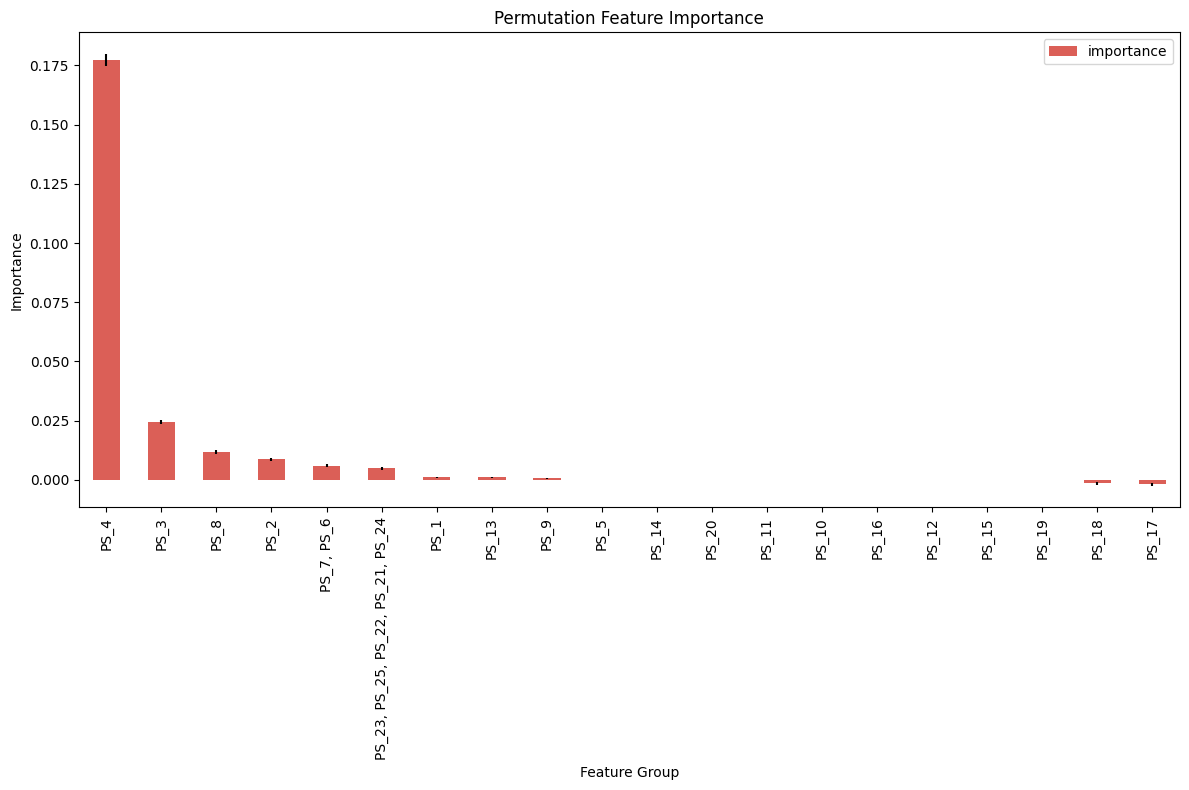

In [27]:
fig, ax = plt.subplots(figsize=(12,8), dpi=100)
pfi_results.plot.bar(
    x='features',
    y='importance',
    yerr='std',
    ax=ax,
    color=sns.color_palette("hls", 1),
)
ax.set_title("Permutation Feature Importance")
ax.set_xlabel("Feature Group")
ax.set_ylabel("Importance")
fig.tight_layout()
plt.show()


We can see several differences when compared to the first permutation feature plot (created withouth groups of correlated features). For example, `PS_6` was originally not important as its performance was basically 0. However, now we can see that it is part of much more important group. Previously, no performance drop was observed as it is correlated with `PS_7`: we permutated `PS_6`, but the model still obtained the information from `PS_6` from `PS_7` feature. But now, as both of these features are permutated at the same time, we got the actual importance of both features. Similar effect can be observed with the `PS_21` and the group where it belongs. Initially, we did not have real importances, but now we can see that it is again part of a group that is far more important for the model's decision making process.

## 3 Partial Dependence Plot

Partial Dependence Plot (PDP) is used to study a relationship between one selected feature and the model outcome. All the values of the selected feature are replaced by a fixed value while the rest of the features stays the same. We obtain model predictions for a range of values used as a fixed value and average such predictions. The resulting average value is called a partial dependence for the selected feature. The process is as follows:
1. Choose a feature `i` in the dataset `X`
2. Replace `X_i` by a fixed values for all rows
3. Get the model predictions for the modified dataset
4. Repeat for a range of values used as the fixed value in the step 2
5. Average the predictions and obtain a partial dependence value for the feature `j`


The scikit-learn library again has a ready-to-use [PartialDependenceDisplay object](https://scikit-learn.org/stable/modules/generated/sklearn.inspection.PartialDependenceDisplay.html) for PDPs that will perform the calculation for us. The first two arguments are the fitted classifier and the dataset. The rest of the arguments are described below:
- `features`: A list of features for which PDP should be calculated. Note that each feature is evaluated separately.
- `response_method`: A method of the estimator that will be used to get the predictions.
- `grid_resolution`: Controls how many values will be evaluated for each feature (higher number means smoother curve, but higher computational complexity).
- `n_cols`: How many PDPs can be plotted on each row, we use one to get one graph per row.
- `ax`: Mathplotlib axes, we use a custom axes to enlarge the resulting plots
- `random_state`: Use the fixed random state to ensure reproducibility.


Note that Partial Dependence Plots require independent features, which is a demanding condition. We will still showcase this method, but keep this requirement in mind. PDP on non-independent features can again provide skewed results.

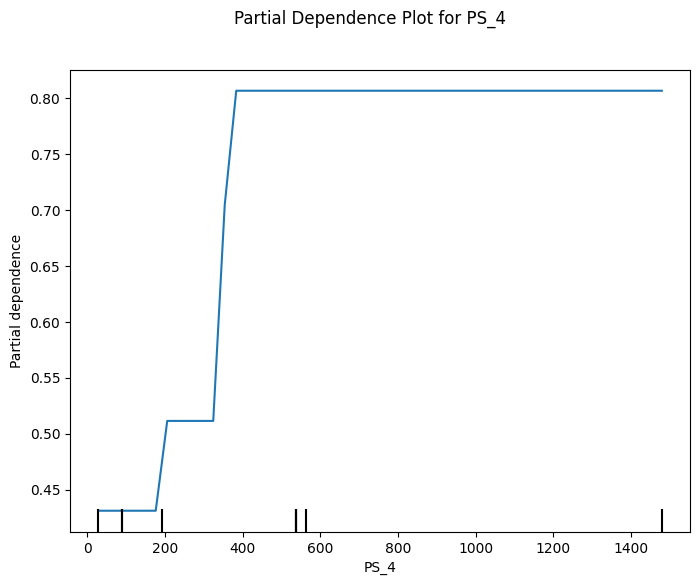

In [28]:
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
partial_dependence_plot = PartialDependenceDisplay.from_estimator(
    random_forest,
    RF_X_train,
    features=['PS_4'],
    target='Game',
    response_method='predict_proba',
    grid_resolution=50,
    n_cols=1,
    ax=ax,
    random_state=RANDOM_STATE
)

partial_dependence_plot.figure_.suptitle("Partial Dependence Plot for PS_4")
plt.show()

The plotted graph tells us average predictions for certain value of the feature: it contains values of the `PS_4` on the x-axis and y-axis shows average prediction. In this case, we set the `response_method` parameter to `predict_proba()` and target class to `Game`. Therefore, y-axis contains average probability predicted for the class `Game`. Consider a point `x=400`: the corresponding y-value is approximately `0.6`. The `~0.6~` value was obtained in the following way: We set the value of `PS_4` to `400` for all the samples in the dataset, and then we used the model to predict probability for the class `Game` for all the samples. Average predicted probability value is then put on the y-axis, in this case the `~0.6`. We can see that the plotted curve is almost constant in some cases and in some cases it has a rising effect. The constant behavior means that as we increased the feature value, predictions were not affected and remained the same, showing very little or no effect on the decision making. Rising/falling regions mean that as we increased/decreased the feature value, average predicted probability was also increasing/decreasing, showing its influence on the model decisions.


Morever, we can also calculate a 2D Partial Dependence Plot (2D PDP). In this case, average predictions are calculated for a pair of fixed features. We will again use the `PartialDependenceDisplay.from_estimator()` method, but the `features` parameter msut be set differently. Now, it is not a list (PDP will be calculated and plotted for each element in the list), but a list of pairs. 2D PDP is calculated for each pair in the passed list. As we previously found out that `PS_6` and `PS_7` are correlated, we will evaluate them together.

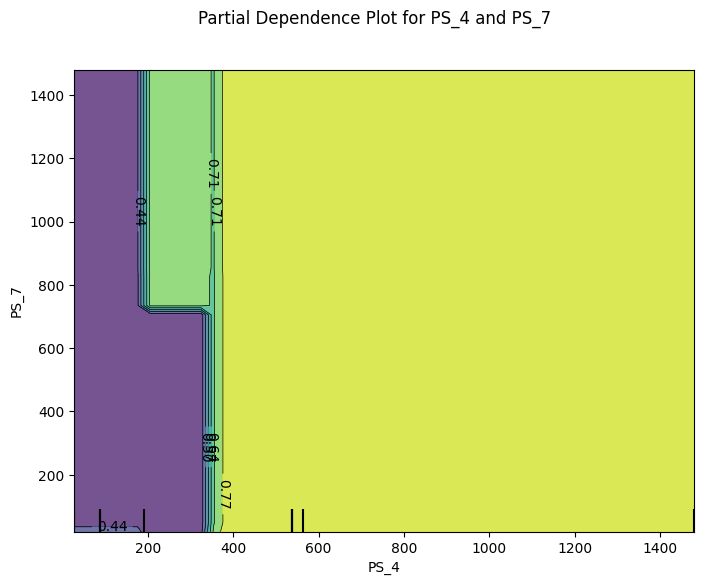

In [29]:
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
partial_dependence_plot = PartialDependenceDisplay.from_estimator(
    random_forest,
    RF_X_train,
    features=[('PS_4', 'PS_7')],
    target='Game',
    response_method='predict_proba',
    grid_resolution=50,
    n_cols=1,
    ax=ax,
    random_state=RANDOM_STATE
)

partial_dependence_plot.figure_.suptitle("Partial Dependence Plot for PS_4 and PS_7")
plt.show()

Here the plot is more complex. Now, the two examined features have the values on x- and y- axes, and the average probability is written inside. We can see how average prediction reaches different thresholds with increasing values of features. In this example, we can see that both features influence on the model's predictions. However, as the `PS_4` gets closer to the value `400`, average prediction reaches `0.77`, and then remains the same.

## 4 Shapley Values

SHAP values are based on a cooperative game theory. Features are considered as players and a model prediction as a payout. After players get the payout (the prediction is made), a fair share of payout is calculated and received by each player: basically how much each feature influenced the made prediction, represented by SHAP values. They show how much features pushed the prediction from a baseline. The baseline is an average prediction across the full dataset, and SHAP values then show how much each feature pushed the prediction away from the baseline. Therefore, the parallel with the game theory can be used to evaluate feature impacts in ML/AI models. SHAP values is a model-agnostic method, implemented in [shap library](shap.readthedocs.io). SHAP values can be calculated on both train and test sets, however, test set is usually prefered.


When calculating SHAP values, we firstly select a feature `X_i` and then:
1. Create all possible subsets of the feature set that **does not** contain `X_i`.
2. For each possible subset, we obtain the model predictions **with** and **without** the `X_i`.
3. Calculate average differences for all possible subsets.


### 4.1 Explaining individual predictions
`Explainer` object takes as the first parameter an object under inspection (can be both a machine-learning model or a function). `Explainer` automatically detects what exact implementation should use, in the case of tree-based models it is `TreeExplainer`. We will use `TreeExplainer` directly, but using `Explainer` would produce the same results. When creating the explainer, we used `feature_perturbation="tree_path_dependent"`: that means that SHAP uses feature splits directly from the model. It approximates the game-theory calculations, it is faster, and can better even highly correlated features. Another option is `feature_perturbation="interventional"`, which follows the game-theoretic Shapley definition, but is slower, and can provide bad results with correlated features. Therefore, we used the `tree_path_dependent` setting. Currently, only supported model output for this setting is `model_output="raw"`: this setting uses raw per-tree scores. After creating the `shap.TreeExplainer`, we obtain SHAP values for the test set.

In [30]:
import shap

shap_explainer = shap.TreeExplainer(
    random_forest,
    feature_perturbation="tree_path_dependent",
    model_output="raw",
    feature_names=RF_X_train.columns.to_list()
)

shap_values = shap_explainer.shap_values(RF_X_test)

print(f'Length of RF_X_test      : {len(RF_X_test)}')
print(f'Shape of the shap_values : {shap_values.shape}')

Length of RF_X_test      : 2293
Shape of the shap_values : (2293, 25, 2)


/Users/plny/Documents/CESNET/ml-flow-class-tutorial/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


When we called `shap_explainer.shap_values()` to obtain the SHAP values, we got a 3D array with the following shape: `(n_samples, n_features, n_classes)`. This is an output that SHAP returns for multiclass problems. Normally, machine-learning models predict only probability for the positive class in binary tasks, therefore, outputting a single value. However, `RandomForestClassifier` outputs a list with probabilities for both classes. This slighty confuses SHAP into treating it as a multiclass task, and providing SHAP values for both classes. Fortunately, it does not matter for us, we can continue with the analysis.


As we have SHAP values for all the samples, we can choose a certain sample and examine what features had biggest impact on the prediction for the chosen sample. Moreover, we have SHAP values for both classes, therefore, we can examine what features had the biggest impact on the probability for both of the candidate classes. We will choose an index, check what ground truth label it is, and use a waterfall plot to visualize SHAP values. `Explanation` object is needed as a parameter, which takes the following parameters:
- `values`: SHAP values of the chosen sample and the class we want to examine.
- `base_values`: expected values of the model's output without using any features, average value of the output
- `data`: the chosen sample from the dataset that is being explained
- `feature_names`: names of the input features


We will plot SHAP values for the chosen sample for both classes. Firstly, we plot SHAP values for the ground truth class `Download` (with index 0).

Ground truth label of this sample: Download, Predicted: Download


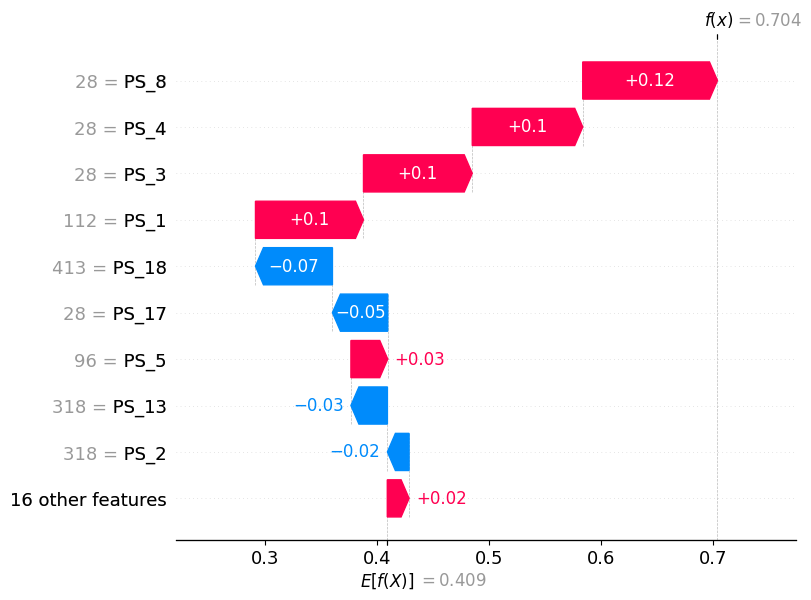

In [31]:
# select a sample or further analysis
sample_index = 550

# check the ground truth label and prediction, to see if the prediction was correct
ground_truth = RF_y_test.iloc[sample_index]
prediction = random_forest.predict(RF_X_test.iloc[sample_index:sample_index+1])[0]
print(f'Ground truth label of this sample: {ground_truth}, Predicted: {prediction}')

# Create shap.Explanation and plot it
exp = shap.Explanation(
    values=shap_values[sample_index, :, 0],
    base_values=shap_explainer.expected_value[0],
    data=RF_X_test.iloc[sample_index],
    feature_names=RF_X_test.columns,
    output_names=random_forest.classes_
)

shap.plots.waterfall(exp)

We can see how features, mainly `PS_8`, `PS_4`, and `PS_3`, influenced the decision making by increasing the probability for the class `Download`. On the other hand, (mainly) features `PS_18` and `PS_17` decreased the probability. Note that we can see the feature values on the left to their names in the plot. We can also see that the average predicted probability is 0.409 while prediction for the chosen sample is the 0.704. Now, we plot SHAP values for the same sample but for the other class `Download` (with index 1).

Ground truth label of this sample: Download, Predicted: Download


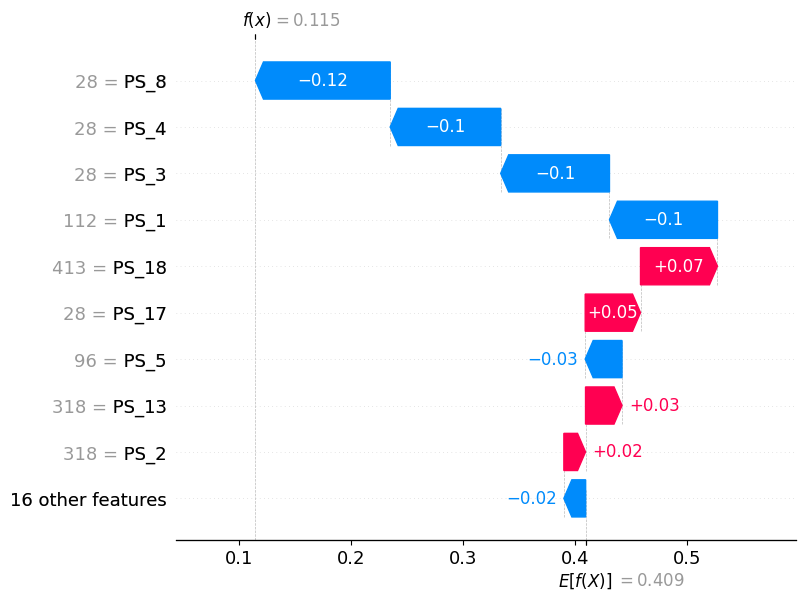

In [32]:
# select a sample for further analysis
sample_index = 550

# check the ground truth label and prediction, to see if the prediction was correct
ground_truth = RF_y_test.iloc[sample_index]
prediction = random_forest.predict(RF_X_test.iloc[sample_index:sample_index+1])[0]
print(f'Ground truth label of this sample: {ground_truth}, Predicted: {prediction}')

# Create shap.Explanation and plot it
exp = shap.Explanation(
    values=shap_values[sample_index, :, 1],
    base_values=shap_explainer.expected_value[0],
    data=RF_X_test.iloc[sample_index],
    feature_names=RF_X_test.columns,
    output_names=random_forest.classes_
)

shap.plots.waterfall(exp)

We can notice that the SHAP values are complementary (due to the nature of a binarty task), as features now have an opposite effect on the decision.

### 4.2 Global Feature Importance through Shapley values


SHAP values can also provide a global view on feature contributions. It is done by averaging the mean SHAP values across the samples. SHAP library has a prepared function `shap.summary_plot()` that takes the SHAP values and corresponding dataset, calculates the mean average, and plots feature contributions. We also set to plot only the top 10 features. As we have per-class SHAP values, we also need to select the target class. We will firstly inspect feature contributions for class `Download`, then `Game`. However, as the task is binary, we should expect the plots to be the same.

In [33]:
def global_shap_importance(class_idx, shap_values, classes, dataset):
    class_name = classes[class_idx]

    plt.figure(dpi=120)
    plt.title(f"Summary plot for class #{class_idx}: {class_name}")

    shap.summary_plot(
        shap_values[:, :, class_idx],
        dataset,
        plot_type="bar",
        max_display=10,
        rng=RANDOM_STATE,
        show=False
    )

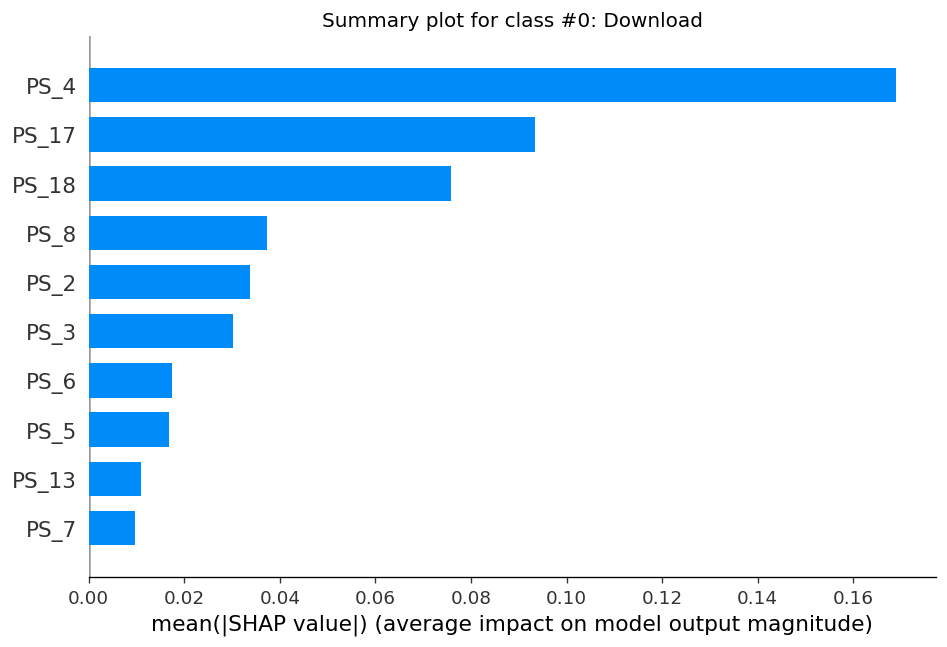

In [34]:
global_shap_importance(0, shap_values, random_forest.classes_, RF_X_test)

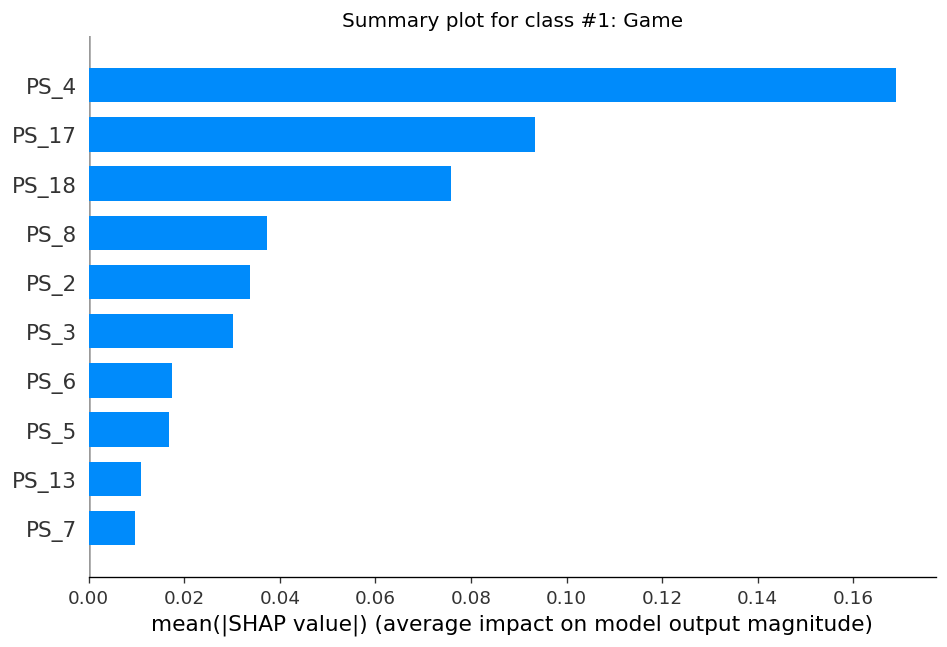

In [35]:
global_shap_importance(1, shap_values, random_forest.classes_, RF_X_test)

## 5 LIME


Local Interpretable Model-agnostic Explanations (LIME) uses a surrogate model, that is more simple and explainable directly. It does not explain the overall complex behavior of the target model, but rather focuses on a single datapoint. A new *local* dataset is created, by pertubating the original datapoint. Many new samples are created from the original datapoint, by using perturbances. Therefore, this new dataset contains only pertubated (slightly different) variants of the original datapoint. Moreover, it is weighted by a distance to the original sample. Then, a surrogate easily explainable model (Linear Regression, Decision Tree, ...) is trained on the new dataset. Finally, parameters learned by the surrogate model (for example coefficients in the case of Linear Regression) show influence of each feature.


We will use `lime` library, especially `LimeTabularExplainer` class, as our data is tabular. In the case of tabualr data, LIME needs the original training set. It is internally used for computing per-feature statistics that are needed for compuping perturbances and distances. Then, we pass feature and class names, set mode to `classification` (the other option is `regression`), and again fix the random state for reproducible results. We can now use the created `explainer` instance to explain individual predictions. We chose the first sample in the test set, as an example, passed to the `data_row` parameter. The `predict_fn` must be set to a function that takes a sample as an input and returns probability array. In the case of scikit-learn, it is a `.predict_proba()`. We also set the `num_features` to 10, therefore, only the top 10 most important features will be returned. The full documentation is available: [here](https://lime-ml.readthedocs.io/en/latest/lime.html#lime.lime_tabular.LimeTabularExplainer.explain_instance) for `explain_instance()`, and [here](https://lime-ml.readthedocs.io/en/latest/lime.html#lime.lime_tabular.LimeTabularExplainer) for the `LimeTabularExplainer`.


Note that the `UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names` is caused by passing the training data as a numpy array, without the feature names. LIME internally uses numpy arrays for its operation. The scikit-learn library produces this warning because numpy arrays do not have the column names, as the original DataFrame did, potentially causing a calculation with wrong feature order. However, as we converted DataFrame to numpy array in the funtion call, features are in the correct order, and we can disregard the warning in this case.

In [36]:
from lime.lime_tabular import LimeTabularExplainer

# Filter out FutureWarning to keep the output simple
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Create a LIME explainer for tabular data
explainer = LimeTabularExplainer(
    training_data=np.array(RF_X_train),
    feature_names=list(RF_X_train.columns),
    class_names=random_forest.classes_,
    mode='classification',
    random_state=RANDOM_STATE
)

# Create an explanation for the selected datapoint, the first sample from test set in this case
lime_explanation = explainer.explain_instance(
    data_row=RF_X_test.iloc[0],
    labels=[0, 1],
    predict_fn=random_forest.predict_proba,
    num_features=10
)


/Users/plny/Documents/CESNET/ml-flow-class-tutorial/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/plny/Documents/CESNET/ml-flow-class-tutorial/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/plny/Documents/CESNET/ml-flow-class-tutorial/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/plny/Documents/CESNET/ml-flow-class-tutorial/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/plny/Documents/CESNET/ml-flow-class-tutorial/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/plny/Documents/CESN

Firstly, we will use `as_list()` function that takes a class, for which we want to evaluate feature contributions, and we can print them. LIME internally uses discretization of features with continuous space, therefore, creating rules and conditions. As we printed the feature contributions, we can see that a threshold (or thresholds) is associated with each feature. For example, `PS_1 <= 32.00` means that for this particular datapoint, having the `PS_1` feature below or equal the value `32` strongly drove the probability for `label=1` (class `Game`) up. Especially, the probability was increased by `0.1685`. On the other hand, when feature `PS_2` contained a value below or equal `32`, the probability for class `Game` was driven down. Such conditions show how each feature value influenced the predicted probability for a certain class. Furhermore, we can plot the feature contributions.

In [37]:
explanation_list = lime_explanation.as_list(label=1)

print("LIME Explanation - Feature Contributions:")
for feature, weight in explanation_list:
    print(f"- {feature:<25}: {weight:.4f}")

LIME Explanation - Feature Contributions:
- PS_1 <= 32.00            : 0.1685
- 88.00 < PS_4 <= 537.00   : 0.1550
- PS_3 <= 20.00            : 0.0932
- 20.00 < PS_17 <= 199.00  : 0.0795
- 88.00 < PS_8 <= 1480.00  : 0.0684
- PS_2 <= 32.00            : -0.0598
- 88.00 < PS_6 <= 1480.00  : 0.0217
- PS_22 <= -1.00           : -0.0134
- PS_25 <= -1.00           : -0.0132
- -1.00 < PS_16 <= 20.00   : 0.0111


Normally, we would now use `lime_explanation.show_in_notebook(show_table=True)`, but as LIME library has not been updated since 2020, there are some compatibility issues with newer Python versions. Especially, the `show_in_notebook()` produces an `ImportError: cannot import name 'display' from 'IPython.core.display'` as it tries to import `display()` function from the old path. However, there are two another options that we can use. We will use `lime_explanation.as_pyplot_figure()` that will use mathplotlib for visualization. This function takes a `label` that will be explained, the default value is `1` (positive classs in binary classification).


Another way is to obtain HTML, and plot it manually with the correctly imported `display()` function (showed below):
```python
from IPython.display import HTML, display
explanation_as_html = lime_explanation.as_html()
display(HTML(html))
```

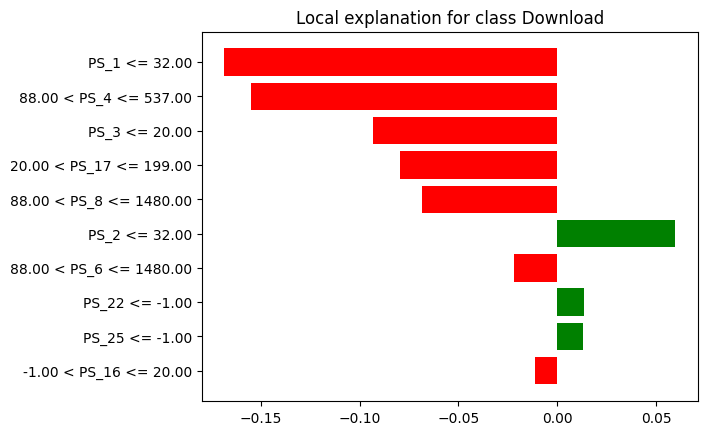

In [38]:
fig = lime_explanation.as_pyplot_figure(label=0)

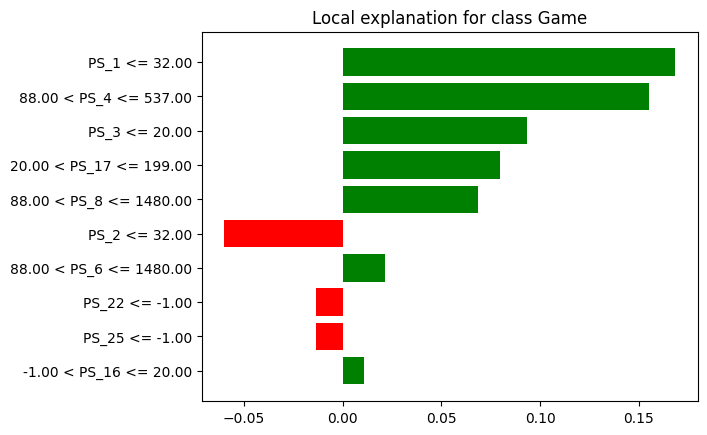

In [39]:
fig = lime_explanation.as_pyplot_figure(label=1)

We plotted explanations for both classes, but again as the task is a binary classification, we can see that the plots are complementary. The y-axis shows features and their corresponding weights/thresholds. The x-axis shows changes in the outputted probability. As we can clearly see, features `PS_1` and `PS_4` together influenced the predicted probability the most.

## 6 Conclusion

This notebook focused on explainability and interpretability of machine learning models. We showcased models that are trivially interpretable due to their nature and do not require any special methods. Then we also showed several model-specific methods that benefit from being embedded into the model itself. However, such methods are not usually transferable to other models. Therefore, we showcased model-agnostic methods that are not bound to specific model, but can be used with any machine learning model, such as Permutation Feature Importance and Shapley values. Some of the presented approaches can produce skewed or biased results when the input features are correlated. It might be needed to group such correlated features into groups, as we shown in the Section 2. Variaty of methods is available for xAI and one should carefully evaluate which method suits the best for his/her own scenario.